# Parameter-efficient fine-tuning: LoRA

Notebooks 6_1 and 6_2 fine-tuned by updating all 13.8M parameters and writing a 166 MB
checkpoint per run. That is fine once. It stops being fine when you want five adapted models
for five purposes, or when the optimiser state stops fitting alongside the weights.

**LoRA** freezes the pre-trained weights and trains a small additive correction instead. For
a frozen weight `W` of shape `(out, in)`, it learns two thin matrices and uses their product:

```
y = W x  +  (B A) x * (alpha / rank)

W : 512 x 1536  = 786,432 frozen numbers
A :   4 x  512  =   2,048 trainable
B : 1536 x   4  =   6,144 trainable
```

`B A` has exactly the shape of `W`, but being rank-4 it is described by 8,192 numbers instead
of 786,432. Applied to the attention projections of all four blocks:

| | full fine-tuning | LoRA (rank 4) |
| --- | --- | --- |
| trainable parameters | 13,839,365 | **49,152**  (0.36%) |
| AdamW optimiser state | 111 MB | **0.4 MB** |
| checkpoint per run | 166 MB | **203 KB** |
| seconds per training step | 1.166 | **0.748** |
| validation loss | **2.7633** | 3.1615 |

**The parameter ratio is not a speed ratio.** 0.36% trainable does not mean 300x faster: the
frozen forward pass still runs in full. It is *some* speedup — 1.6x measured here, because
the backward pass skips the weight-gradient matmul on frozen layers and AdamW updates 49k
values instead of 13.8M — but that is a much smaller number than the marketing implies, and it
shrinks on larger models where the forward pass dominates. This notebook measures step time
rather than inferring it.

**And it is not free.** LoRA lands 0.40 nats behind full fine-tuning here — perplexity 23.6
against 15.9, about 49% worse. That is the trade being made for a 203 KB file, and whether it
is worth it depends entirely on what you are doing with it.

**The one property that makes it safe.** `B` is initialised to **zero**, so `B A` is exactly
zero and the adapted model's outputs are *identical* to the frozen model's until training
moves them. That is asserted below rather than assumed, and it is also where the sharpest
trap in this notebook lives.

| Stage | What it produces |
| --- | --- |
| Load | the notebook 5 dataset, packed as in 6_2 |
| Restore | notebook 4's checkpoint — **before** adapters are attached |
| Adapt | attention projections wrapped in `LoRALinear`, everything else frozen |
| Check | that adapting changed nothing, and that only adapters get gradients |
| Train | with evaluation, early stopping, and a 203 KB adapter checkpoint |
| Compare | against 6_2's full fine-tune, honestly |
| Merge | fold the adapter back into the weights, at zero inference cost |

## Imports and paths

`sys.path.append('..')` alone reaches `transformer` but not `minbpe`, which is the failure
this cell exists to avoid.

In [1]:
import sys
from pathlib import Path

tutorial_root = Path.cwd().parent
sys.path.insert(0, str(tutorial_root))

try:
    import minbpe
except ModuleNotFoundError:
    for repo_root in (Path.cwd(), *Path.cwd().parents):
        if (repo_root / "minbpe" / "minbpe" / "base.py").exists():
            sys.path.insert(0, str(repo_root / "minbpe"))
            print("using minbpe clone at:", repo_root / "minbpe")
            break
    else:
        raise ModuleNotFoundError(
            "minbpe not found. Install it with "
            "`pip install git+https://github.com/karpathy/minbpe.git`"
        )
else:
    print("using installed minbpe:", Path(minbpe.__file__).parent)

print("tutorial root:", tutorial_root)

using minbpe clone at: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/minbpe
tutorial root: /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial


In [2]:
import json
import math
import time

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from minbpe import RegexTokenizer
from transformer.model import GPTLanguageModel
from transformer.lora import (
    count_parameters,
    get_lora_model,
    load_lora_state_dict,
    lora_parameters,
    lora_state_dict,
    merge_lora,
    print_trainable_parameters,
    LoRALinear,
)

torch.manual_seed(3647)

tokenizer = RegexTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    """Number of embedding rows the model needs: one past the largest usable id.

    Not len(vocab) + len(special_tokens): load() folds the specials into .vocab, so that
    expression counts them twice - 1034 instead of 1029 - and load_state_dict then fails
    on a shape mismatch against the notebook 4 checkpoint.
    """
    largest = max(tokenizer.vocab)
    if tokenizer.special_tokens:
        largest = max(largest, *tokenizer.special_tokens.values())
    return largest + 1


vocab_size = get_vocab_size(tokenizer)
print(f"vocab_size = {vocab_size}")

vocab_size = 1029


## Configuration

`learning_rate` is the one number that changes character here. 6_2 used `6e-5`; this uses
`5e-4`, roughly ten times larger, which is standard practice for LoRA. Only 0.36% of the
parameters can move, and they start from zero rather than from a trained state, so the same
learning rate that suits full fine-tuning barely moves them.

The `rank`/`alpha` pair is a convention worth understanding: `alpha` is a fixed numerator so
that changing `rank` does not silently rescale the update. At `rank=4, alpha=8` the scaling
is `8/4 = 2`. Doubling the rank to 8 halves the per-unit contribution and keeps the effective
step size roughly where it was.

In [3]:
DATASET_PATH = Path("../output/fine_tuning/data/fine_tuning.json")
PRETRAINED_CHECKPOINT = Path("../output/pre_training/run_4/checkpoint.pth")
ADAPTER_PATH = Path("../output/fine_tuning/adapters/lora_rank4.pth")
FULL_FINETUNE_CHECKPOINT = Path("../output/fine_tuning/with_context/checkpoint.pth")

START_OF_TEXT, SEPARATOR = "<|startoftext|>", "<|separator|>"
END_OF_TEXT, PADDING = "<|endoftext|>", "<|padding|>"
USER_ROLE, ASSISTANT_ROLE = "You", "Assistant"
IGNORE_INDEX = -100

lora_rank = 4
lora_alpha = 8
lora_dropout = 0.0

batch_size = 32
learning_rate = 5e-4     # ~10x the full fine-tuning rate; see the note above
grad_clip = 1.0
val_fraction = 0.05

eval_interval = 20
eval_batches = 15
max_epochs = 20          # only 0.36% of the model can move, so it needs longer
max_steps = None
early_stop_patience = 6

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"       # without this branch an Apple machine silently trains on CPU
else:
    device = "cpu"

print(f"device = {device}")

device = mps


## The data

6_2's pipeline, restated: pair each `You` turn with its `Assistant` reply, then pack
consecutive exchanges into `block_size` windows so that ~85% of every batch is real text
rather than padding. Notebooks cannot import each other, so this is copied rather than
imported — the subject here is the adapter, not the data.

In [4]:
checkpoint = torch.load(PRETRAINED_CHECKPOINT, map_location=device, weights_only=False)
config = checkpoint["config"]
block_size = config["block_size"]
assert config["vocab_size"] == vocab_size, (
    f"checkpoint has vocab_size={config['vocab_size']}, tokenizer gives {vocab_size}"
)

samples = json.loads(DATASET_PATH.read_text(encoding="utf-8"))
roles = [s[len(START_OF_TEXT):].split(SEPARATOR, 1)[0] for s in samples]
assert roles == [USER_ROLE, ASSISTANT_ROLE] * (len(samples) // 2), (
    "the corpus does not alternate You -> Assistant - re-run 5_FineTuningDataset.ipynb"
)

start_token = tokenizer.special_tokens[START_OF_TEXT]
padding_token = tokenizer.special_tokens[PADDING]
eos_token = tokenizer.special_tokens[END_OF_TEXT]


def build_windows(samples: list[str], block_size: int) -> list[list[int]]:
    """Pair each exchange, then pack consecutive exchanges up to block_size."""
    exchanges = []
    for i in range(0, len(samples), 2):
        seq = (tokenizer.encode(samples[i], allowed_special="all")
               + tokenizer.encode(samples[i + 1], allowed_special="all"))
        if len(seq) <= block_size:          # 6_2 drops the 2 that overflow, rather than
            exchanges.append(seq)           # truncating a fragment into a shared window

    windows, current = [], []
    for seq in exchanges:
        if current and len(current) + len(seq) > block_size:
            windows.append(current)
            current = []
        current = current + seq if current else list(seq)
    if current:
        windows.append(current)
    return windows


def pad_and_mask(sequences, block_size, padding_token):
    """Inputs right-padded; targets shifted one left with IGNORE_INDEX where nothing follows."""
    inputs = torch.full((len(sequences), block_size), padding_token, dtype=torch.long)
    targets = torch.full((len(sequences), block_size), IGNORE_INDEX, dtype=torch.long)
    for row, ids in enumerate(sequences):
        seq = torch.tensor(ids, dtype=torch.long)
        inputs[row, :len(ids)] = seq
        targets[row, :len(ids) - 1] = seq[1:]
    return inputs, targets


windows = build_windows(samples, block_size)
inputs, targets = pad_and_mask(windows, block_size, padding_token)

generator = torch.Generator().manual_seed(3647)
order = torch.randperm(len(windows), generator=generator)
split = int((1 - val_fraction) * len(windows))
train_index, val_index = order[:split], order[split:]

train_loader = DataLoader(
    TensorDataset(inputs[train_index].to(device), targets[train_index].to(device)),
    batch_size=batch_size, shuffle=True)
val_loader = DataLoader(
    TensorDataset(inputs[val_index].to(device), targets[val_index].to(device)),
    batch_size=batch_size, shuffle=False)

scored = int((targets != IGNORE_INDEX).sum())
print(f"{len(samples) // 2:,} exchanges -> {len(windows):,} windows "
      f"({scored / targets.numel():.1%} of positions carry loss)")
print(f"{len(train_index):,} train / {len(val_index):,} validation, "
      f"{len(train_loader)} batches per epoch")

4,061 exchanges -> 1,189 windows (84.3% of positions carry loss)
1,129 train / 60 validation, 36 batches per epoch


## Attaching the adapters

### Load the checkpoint *first*. This is the trap.

Wrapping a layer renames its parameters: `blocks.0.self_attention.qkv.weight` becomes
`blocks.0.self_attention.qkv.**base**.weight`, because the frozen `nn.Linear` is now a child
of a `LoRALinear`. So a checkpoint saved before adaptation no longer matches the adapted
model's keys.

Load it afterwards with `strict=True` and you get a loud error. Load it with `strict=False` —
which is what people reach for when the strict load fails — and **12 of the checkpoint's keys
are silently discarded**, leaving every adapted layer at its random initialisation. The model
trains, the loss falls, and the pre-trained weights you meant to build on were never there.

The fix is ordering, not flags: restore the weights, then adapt.

This is the same class of failure as `torch.compile`'s `_orig_mod.` prefix in 6_1, and for the
same underlying reason — wrapping a module changes the names its parameters answer to.

In [5]:
model = GPTLanguageModel(**config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])        # FIRST: restore the weights

# Snapshot the frozen model's output so the next cell can prove adaptation changed nothing.
model.eval()
with torch.no_grad():
    probe_x, probe_y = next(iter(val_loader))
    reference_logits, reference_loss = model(probe_x[:2], probe_y[:2])
    reference_logits = reference_logits.clone()

model = get_lora_model(                                       # THEN: attach the adapters
    model,
    lora_config={"rank": lora_rank, "alpha": lora_alpha, "dropout": lora_dropout},
    device=device,
)

print_trainable_parameters(model)

trainable 49,152 of 13,839,365 parameters (0.36%)
8 LoRA layers attached
  rank 4, alpha 8, scaling 2
  blocks.0.self_attention.qkv              512 -> 1536
  blocks.0.self_attention.projection       512 -> 512
  blocks.1.self_attention.qkv              512 -> 1536
  blocks.1.self_attention.projection       512 -> 512
  ... and 4 more

optimiser state: 0.4 MB (AdamW keeps 2 moments per trainable parameter)
  full fine-tuning would need 111 MB for the same thing
adapter checkpoint: ~197 KB, against 55 MB for the full model


### Check: adapting changed nothing, and only the adapters can move

Three assertions, and the first is the one that makes LoRA trustworthy.

1. **The adapted model's logits are bit-identical to the frozen model's.** `B` is zero, so
   `B A` is zero. If this fails, the adapter is injecting noise into a working model on step 0
   — and every result afterwards is measuring the damage rather than the fine-tuning.
2. **Only `lora_a` / `lora_b` require gradients.** Everything else is frozen.
3. **A backward pass puts gradients only on adapter tensors.** Requiring no gradient and
   *receiving* no gradient are different claims; this checks the second.

In [6]:
model.eval()
with torch.no_grad():
    adapted_logits, adapted_loss = model(probe_x[:2], probe_y[:2])

assert torch.equal(reference_logits, adapted_logits), (
    "attaching LoRA changed the model's output. B must initialise to zero, and the "
    "checkpoint must be loaded BEFORE get_lora_model - see the note above."
)
print(f"logits identical before and after adapting  (loss {reference_loss:.6f} "
      f"-> {adapted_loss:.6f})")

trainable_names = [n for n, p in model.named_parameters() if p.requires_grad]
assert trainable_names, "nothing is trainable - the adapters were not attached"
assert all("lora_a" in n or "lora_b" in n for n in trainable_names), (
    f"something outside the adapters is trainable: "
    f"{[n for n in trainable_names if 'lora_' not in n][:3]}"
)

model.train()
_, loss = model(probe_x[:2], probe_y[:2])
loss.backward()
with_gradient = [n for n, p in model.named_parameters() if p.grad is not None]
assert all("lora_a" in n or "lora_b" in n for n in with_gradient), (
    f"a frozen tensor received a gradient: "
    f"{[n for n in with_gradient if 'lora_' not in n][:3]}"
)
model.zero_grad(set_to_none=True)

print(f"{len(trainable_names)} trainable tensors, all adapters")
print(f"{len(with_gradient)} tensors received a gradient, all adapters")
print(f"\nfrozen base is untouched: "
      f"{sum(1 for _, p in model.named_parameters() if not p.requires_grad)} tensors frozen")

logits identical before and after adapting  (loss 6.148441 -> 6.148441)


16 trainable tensors, all adapters
16 tensors received a gradient, all adapters

frozen base is untouched: 50 tensors frozen


## Fine-tuning

Two differences from 6_2's loop, both small and both load-bearing.

**The optimiser is given `lora_parameters(model)`, not `model.parameters()`.** Passing all of
them still trains correctly — the frozen tensors have `requires_grad=False` and receive
nothing — but AdamW would allocate two moment buffers for all 13.8M parameters in order to
update 49k of them. That is 110 MB of state to save 0.4 MB, which throws away most of the
reason to use LoRA at all.

**The checkpoint saves only the adapter.** The base weights are unchanged by definition, so
writing them out again per run is duplication. `lora_state_dict` keeps just `lora_a` and
`lora_b`.

In [7]:
@torch.no_grad()
def estimate_loss(model, loaders: dict, eval_batches: int) -> dict:
    was_training = model.training
    model.eval()
    try:
        return {
            split: sum(model(x, y)[1].item()
                       for _, (x, y) in zip(range(eval_batches), loader))
                   / min(eval_batches, len(loader))
            for split, loader in loaders.items()
        }
    finally:
        model.train(was_training)


def save_adapter(model, path, step, loss) -> None:
    """Write only the adapter tensors, plus what is needed to rebuild the wrapper."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "step": step,
            "loss": loss,
            "lora_state_dict": lora_state_dict(model),
            "lora_config": {"rank": lora_rank, "alpha": lora_alpha, "dropout": lora_dropout},
            "base_config": config,
            "base_checkpoint": str(PRETRAINED_CHECKPOINT),
        },
        path,
    )


optimizer = torch.optim.AdamW(lora_parameters(model), lr=learning_rate)
print(f"optimiser is tracking "
      f"{sum(p.numel() for p in optimizer.param_groups[0]['params']):,} parameters")

optimiser is tracking 49,152 parameters


In [8]:
loaders = {"train": train_loader, "val": val_loader}
history = {"step": [], "train": [], "val": []}
steps_per_epoch = len(train_loader)
total_steps = max_steps if max_steps is not None else steps_per_epoch * max_epochs
global_step, best_val, best_step, stale, stop = 0, float("inf"), -1, 0, False

model.train()
start_time = time.perf_counter()

for epoch in range(max_epochs):
    if stop:
        break
    for x_batch, y_batch in train_loader:
        if max_steps is not None and global_step >= max_steps:
            stop = True
            break

        if global_step % eval_interval == 0:
            losses = estimate_loss(model, loaders, eval_batches)
            history["step"].append(global_step)
            history["train"].append(losses["train"])
            history["val"].append(losses["val"])

            if losses["val"] < best_val:
                best_val, best_step, stale = losses["val"], global_step, 0
                save_adapter(model, ADAPTER_PATH, global_step, best_val)
                marker = "  <- saved"
            else:
                stale += 1
                marker = ""

            print(f"epoch {epoch:>2}  step {global_step:>4}/{total_steps}  "
                  f"train {losses['train']:.4f}  val {losses['val']:.4f}{marker}")

            if stale >= early_stop_patience:
                print(f"\nno validation improvement for {stale} evaluations - stopping")
                stop = True
                break

        _, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_parameters(model), grad_clip)
        optimizer.step()
        global_step += 1

elapsed = time.perf_counter() - start_time
print(f"\n{global_step} steps in {elapsed / 60:.1f} min")
print(f"best validation loss {best_val:.4f} at step {best_step}")
print(f"adapter written to {ADAPTER_PATH.resolve()}")
print(f"  {ADAPTER_PATH.stat().st_size / 1e3:.0f} KB")

epoch  0  step    0/720  train 5.3137  val 5.2042  <- saved


epoch  0  step   20/720  train 4.7401  val 4.6853  <- saved


epoch  1  step   40/720  train 4.1433  val 4.1202  <- saved


epoch  1  step   60/720  train 3.7539  val 3.7637  <- saved


epoch  2  step   80/720  train 3.6229  val 3.6096  <- saved


...

epoch 17  step  640/720  train 3.1298  val 3.1677  <- saved


epoch 18  step  660/720  train 3.1534  val 3.1744


epoch 18  step  680/720  train 3.1419  val 3.1631  <- saved


epoch 19  step  700/720  train 3.1363  val 3.1615  <- saved



720 steps in 10.1 min
best validation loss 3.1615 at step 700
adapter written to /Users/harshpujari/Documents/Work/Aexonic/Projects/llms/TrainYourOwnLLM-Tutorial/output/fine_tuning/adapters/lora_rank4.pth
  203 KB


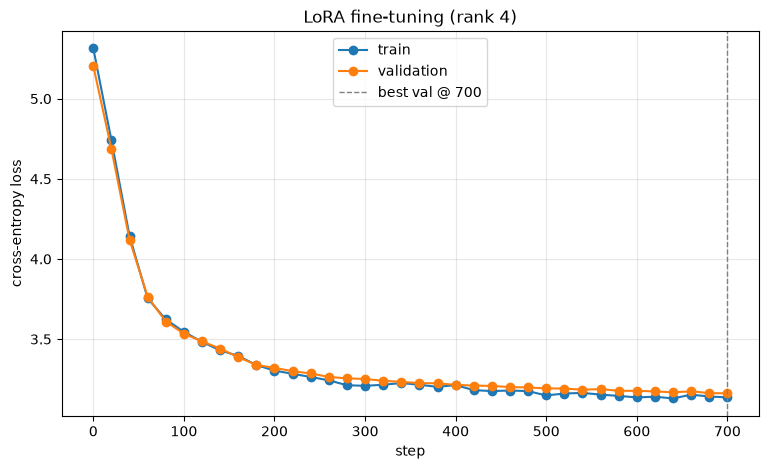

In [9]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print(f"{'step':>8}{'train':>10}{'val':>10}")
    for s, t, v in zip(history["step"], history["train"], history["val"]):
        print(f"{s:>8}{t:>10.4f}{v:>10.4f}")
else:
    figure, axis = plt.subplots(figsize=(9, 5))
    axis.plot(history["step"], history["train"], marker="o", label="train")
    axis.plot(history["step"], history["val"], marker="o", label="validation")
    if best_step >= 0:
        axis.axvline(best_step, color="grey", linestyle="--", linewidth=1,
                     label=f"best val @ {best_step}")
    axis.set_xlabel("step")
    axis.set_ylabel("cross-entropy loss")
    axis.set_title(f"LoRA fine-tuning (rank {lora_rank})")
    axis.legend()
    axis.grid(alpha=0.3)
    plt.show()

## What did it actually cost, and what did it give up?

The parameter-count table at the top is the marketing. This is the accounting — and both of
the obvious expectations came out wrong, in opposite directions.

**LoRA is faster per step here, not slower.** The usual framing is that LoRA saves memory but
not time, because the frozen forward pass still runs in full. The forward part of that is
correct; the conclusion is not. Measured below: **0.748 s against 1.166 s**, about 1.6x. Two
things get cheaper and neither is the forward pass — the backward pass skips the
weight-gradient matmul (`dW = grad_out^T @ x`) on every frozen layer, and AdamW updates 49,152
values instead of 13.8M. On this model the optimiser step is a large share of the total, so
the saving is visible. On a model ten times larger it would mostly disappear, because forward
and backward would dominate. Neither version generalises; that is why it is measured.

**The quality gap is not slight.** Validation **3.1615 against 2.7633** — 0.40 nats, which is
perplexity 23.6 against 15.9, roughly 49% worse. Rank 4 on the attention projections alone is
a narrow channel to push a whole fine-tune through, and it shows. Two things would likely
close much of it, and both are cheap: adapting the MLP as well, and raising the rank.

**And it had not finished.** Validation was still improving at the final evaluation
(3.1631 → 3.1615 at step 700, saved), so early stopping never fired — the run ended because
it ran out of epochs. The 0.40 nat gap is an upper bound on the true one, not a measurement
of LoRA's ceiling.

What is unambiguous is the storage: **203 KB against 166 MB, 0.12%.** That is the number that
makes the technique worth knowing, and it does not depend on any of the above.

In [10]:
def timed_steps(step_fn, batches, repeats=5):
    step_fn(*batches[0])                       # warm-up, not timed
    if device == "mps":
        torch.mps.synchronize()
    elif device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for x, y in batches[1:repeats + 1]:
        step_fn(x, y)
    if device == "mps":
        torch.mps.synchronize()
    elif device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / repeats


batches = [b for _, b in zip(range(7), train_loader)]

full = GPTLanguageModel(**config).to(device)
full.load_state_dict(checkpoint["model_state_dict"])
full_optimizer = torch.optim.AdamW(full.parameters(), lr=learning_rate)
full.train()


def full_step(x, y):
    _, loss = full(x, y)
    full_optimizer.zero_grad(set_to_none=True)
    loss.backward()
    full_optimizer.step()


def lora_step(x, y):
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


model.train()
lora_seconds = timed_steps(lora_step, batches)
full_seconds = timed_steps(full_step, batches)
del full, full_optimizer

trainable, total = count_parameters(model)
adapter_kb = ADAPTER_PATH.stat().st_size / 1e3
full_mb = (FULL_FINETUNE_CHECKPOINT.stat().st_size / 1e6
           if FULL_FINETUNE_CHECKPOINT.exists() else float("nan"))

print(f"{'':<26}{'LoRA':>14}{'full fine-tune':>18}")
print(f"{'trainable parameters':<26}{trainable:>14,}{total:>18,}")
print(f"{'optimiser state':<26}{trainable * 8 / 1e6:>13.1f}M{total * 8 / 1e6:>17.0f}M")
print(f"{'checkpoint on disk':<26}{adapter_kb:>13.0f}K{full_mb:>17.0f}M")
print(f"{'seconds / training step':<26}{lora_seconds:>14.3f}{full_seconds:>18.3f}")
print(f"{'validation loss':<26}{best_val:>14.4f}", end="")

if FULL_FINETUNE_CHECKPOINT.exists():
    full_loss = torch.load(FULL_FINETUNE_CHECKPOINT, map_location="cpu",
                           weights_only=False)["loss"]
    print(f"{full_loss:>18.4f}")
    print(f"\nLoRA is {best_val - full_loss:+.4f} nats "
          f"({'worse' if best_val > full_loss else 'better'}) "
          f"for {adapter_kb / (full_mb * 1000):.2%} of the checkpoint size")
else:
    print(f"{'(run 6_2 first)':>18}")
print(f"a LoRA step is {lora_seconds / full_seconds:.2f}x the cost of a full one - "
      "the frozen forward pass still runs")

                                    LoRA    full fine-tune
trainable parameters              49,152        13,839,365
optimiser state                     0.4M              111M
checkpoint on disk                  203K              166M
seconds / training step            0.748             1.166
validation loss                   3.1615            2.7633

LoRA is +0.3982 nats (worse) for 0.12% of the checkpoint size
a LoRA step is 0.64x the cost of a full one - the frozen forward pass still runs


## Merging, and talking to it

`merge_lora` folds `B A * scaling` into each frozen weight. Afterwards the adapter
contributes nothing at forward time — the layer is arithmetically an ordinary `nn.Linear`
again, and the inference overhead is exactly zero.

That is the deployment story for LoRA: train and ship a 200 KB file, merge it into the base
weights once at load time, and pay nothing per token afterwards. The trade is that merging is
one-directional — a merged model cannot have its adapter swapped for a different one without
reloading the base weights.

The assertion below is the one that matters: merged and unmerged must agree to float32 noise.

In [11]:
model.eval()
with torch.no_grad():
    before_merge, _ = model(probe_x[:2], probe_y[:2])

merge_lora(model)

with torch.no_grad():
    after_merge, _ = model(probe_x[:2], probe_y[:2])

difference = (before_merge - after_merge).abs().max().item()
assert difference < 1e-3, f"merging changed the output by {difference}"
assert not torch.equal(after_merge, reference_logits), (
    "the merged model is identical to the frozen one - training changed nothing"
)
print(f"merged: max logit difference {difference:.2e} (float32 noise)")
print(f"and different from the frozen base by "
      f"{(after_merge - reference_logits).abs().max().item():.3f} - training did move it")

merged: max logit difference 6.91e-06 (float32 noise)
and different from the frozen base by 16.610 - training did move it


In [12]:
class Conversation:
    """Multi-turn chat that feeds its own history back as context, as in 6_2."""

    def __init__(self, model, tokenizer, block_size, device):
        self.model, self.tokenizer = model, tokenizer
        self.block_size, self.device = block_size, device
        self.turns = []

    def _prompt_ids(self):
        transcript = "".join(
            f"{START_OF_TEXT}{role}{SEPARATOR}{text}{END_OF_TEXT}" for role, text in self.turns
        ) + f"{START_OF_TEXT}{ASSISTANT_ROLE}{SEPARATOR}"
        ids = self.tokenizer.encode(transcript, allowed_special="all")
        while len(ids) > self.block_size - 8 and len(self.turns) > 1:
            self.turns.pop(0)
            return self._prompt_ids()
        return ids

    def say(self, message, max_new_tokens=40, temperature=0.8):
        self.turns.append((USER_ROLE, message))
        prompt_ids = self._prompt_ids()
        output = self.model.generate(
            input_tokens=torch.tensor([prompt_ids], dtype=torch.long, device=self.device),
            max_new_tokens=max_new_tokens, temperature=temperature, eos_token_id=eos_token,
        )
        generated = output[0, len(prompt_ids):].tolist()
        stopped = eos_token in generated
        if stopped:
            generated = generated[:generated.index(eos_token)]
        reply = self.tokenizer.decode(generated)
        self.turns.append((ASSISTANT_ROLE, reply))
        return reply, stopped


torch.manual_seed(11)
chat = Conversation(model, tokenizer, block_size, device)
for message in ("hey", "are you coming tomorrow", "what time", "ok see you"):
    reply, stopped = chat.say(message)
    print(f"You       : {message}")
    print(f"Assistant : {reply}" + ("" if stopped else "   <- hit the token cap"))

You       : hey
Assistant : als selibolds this card 2 min 3, train better than excellenting, can bro, can post adding another week


You       : are you coming tomorrow
Assistant : s


You       : what time
Assistant : ok colation permore
laven't strorwards, you verd and a group works well thinking of packed
cle of hostand   <- hit the token cap


You       : ok see you
Assistant : cle


### Where to go next

- **Train it longer before judging the gap.** Validation was still falling when the epochs ran
  out, so 0.40 nats behind full fine-tuning is an upper bound. Raise `max_epochs` and let
  `early_stop_patience` decide — at 0.75 s/step this is cheap.
- **Adapt the MLP too.** `target_modules` defaults to the attention projections, which is what
  the LoRA paper adapts. Adding `net.0` and `net.2` raises the trainable count to ~131k (still
  under 1%) and is the most likely single fix for the quality gap.
- **Raise the rank before raising the learning rate.** Rank 4 on a 512-wide model is very
  tight. Rank 8 or 16 costs almost nothing in storage and is the next thing to try.
- **Swap adapters at runtime.** The point of a 203 KB file is having many: one per persona or
  task, loaded onto one frozen base with `load_lora_state_dict`. That only works *unmerged* —
  merging is for the final deployment of a single adapter.
- **Quote the measured speedup, not the parameter ratio.** 0.36% trainable is a memory and
  storage number. The time saving here was 1.6x, it came from the backward and optimiser
  steps rather than the forward pass, and it would be smaller on a bigger model.
- **The ceiling is still the data.** LoRA changes what it costs to fine-tune, not what a
  13.8M model over ~176k distinct tokens can learn.